# Solar radiation on facades and roofs, in 3D

**Question:** which facades and roofs of a dense city block get the most sun in summer?
The answer helps you place solar panels, find facades with an overheating risk,
and choose where facade greening is useful.

**Site:** Karlsplatz, Vienna. 123 real footprints with heights (OpenStreetMap), from
`../sample-data/vienna-demo`. This is your own model: replace the GeoJSON with your buildings.

**Steps**
1. Make closed building meshes from the footprints.
2. Read the summer weather from an EPW file.
3. Make a solar radiation request with sensors on facades and roofs.
4. Preview the jobs and the cost (free).
5. Run, then summarise each building.
6. Draw the result in 3D (PNG) and, if you want, as an interactive HTML file.

You need `INFRARED_API_KEY` in your environment. Docs: [Facade and roof runs](https://infrared.city/docs/sdk/#facade-and-roof-runs).

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from infrared_sdk import InfraredClient, parse_epw
from infrared_sdk.analyses.types import AnalysesName, SolarRadiationModelRequest
from infrared_sdk.models import TimePeriod

import ir_site as site
import ir_view3d as v3

os.environ.setdefault("INFRARED_QUIET", "1")  # no SDK progress lines in the notebook
logging.getLogger("infrared_sdk.sdk").setLevel(logging.ERROR)  # no "default base URL" note
client = InfraredClient()  # reads INFRARED_API_KEY
OUT = Path("outputs")
DATA = Path("../sample-data/vienna-demo/scenarios/01-baseline")

## 1. Your buildings

The run polygon is the bounding box of the footprints plus 30 m. Its south-west corner is
the origin (0, 0, 0) of the model. `site.extrude` makes one closed solid (bottom, walls, top)
for each footprint, in metres.

In [2]:
footprints = site.read_geojson(DATA / "buildings.geojson")
polygon = site.polygon_around(footprints["features"], pad_m=30)
origin = site.origin_of(polygon)
buildings = site.buildings_from_geojson(footprints, origin)  # {id: {coordinates, indices}}

width, depth = site.size_m(polygon)
print(f"{len(buildings)} buildings on a site of {width:.0f} m x {depth:.0f} m")

123 buildings on a site of 577 m x 607 m


## 2. Weather and time window

Solar radiation reads two weather columns: direct normal and diffuse horizontal radiation.
`model_inputs` takes them from the EPW file for your window and checks for gaps before you pay.

In [3]:
weather = parse_epw(site.fetch_epw())  # Vienna TMYx, downloaded once into ./cache
summer = TimePeriod(start_month=6, start_day=1, start_hour=8, end_month=8, end_day=31, end_hour=18)
radiation = weather.model_inputs(analysis_type="solar-radiation", time_period=summer)
print(f"{len(radiation['direct_normal_radiation'])} hours from {weather.location['city']}")

1012 hours from Wien-Schwechat.AP


## 3. The request

`analysis_surfaces="all"` puts a sensor grid on every facade and roof. It replaces the ground
grid. `surface_grid_size=2.0` gives one sensor for each 2 m x 2 m cell.

In [4]:
lon, lat = np.mean(polygon["coordinates"][0][:4], axis=0)
request = SolarRadiationModelRequest(
    analysis_type=AnalysesName.solar_radiation,
    latitude=lat,
    longitude=lon,
    time_period=summer,
    analysis_surfaces="all",
    surface_grid_size=2.0,
    **radiation,
)

## 4. Preview: jobs and cost

The preview is local and free. Give `payload=`, so that the SDK counts the facade sensors
and the batches exactly.

In [5]:
preview = client.preview_area(polygon, payload=request, buildings=buildings)
print(f"tiles {preview.tile_count}, jobs {preview.would_bill_jobs}, "
      f"sensors {preview.sensor_count:,}, cost {preview.estimated_cost_tokens} tokens")

tiles 4, jobs 3, sensors 101,192, cost 30 tokens


## 5. Run and summarise

The result has one value for each facade and roof cell. `building_aggregates` gives the
area, the mean and the peak for each building.

In [6]:
result = client.run_area_and_wait(request, polygon, buildings=buildings)
print(f"{len(result.surfaces)} surfaces, values {result.min_legend:.0f} to {result.max_legend:.0f} kWh/m²")

names = {f"b{i:03d}": f["properties"].get("name") or "" for i, f in enumerate(footprints["features"])}
rows = [
    {"building": names.get(bid, bid) or bid, "surface m²": agg.area,
     "mean kWh/m²": agg.mean, "total MWh": agg.area * agg.mean / 1000}
    for bid, agg in result.building_aggregates.items()
]
table = pd.DataFrame(rows).sort_values("total MWh", ascending=False).head(8)
table.style.format(precision=0).hide(axis="index")

2585 surfaces, values 0 to 439 kWh/m²


building,surface m²,mean kWh/m²,total MWh
"TU Wien, Hauptgebäude",25056,258,6470
Karlskirche,13276,210,2782
Musikverein,10824,253,2741
Künstlerhaus Wien,10656,256,2729
Vienna Business School Akademiestraße,10564,190,2011
Kreuzherrenhof,7760,237,1837
Wien Museum Karlsplatz,5828,302,1762
"TU Wien, Campus Gußhaus, Altes EI",6788,251,1703


**What you see:** the large blocks collect the most energy in total. Their flat roofs give
most of it. The mean value shows how well a building is exposed, independent of its size.

## 6. Facades and roofs: two different worlds

`render_buffers()` gives the cells as a few flat arrays. `v3.cells_mesh` turns them into
triangles and cuts the edge cells to the exact outline of each surface.

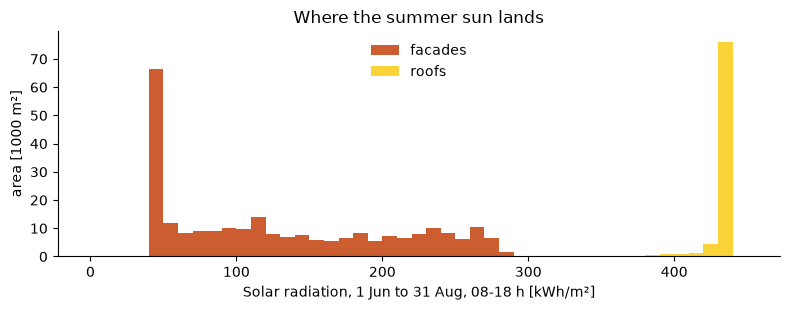

In [7]:
cells = v3.cells_mesh(result.columns.render_buffers())
wall = v3.is_wall(cells)
value = cells.cell_data["value"]
area = cells.compute_cell_sizes(length=False, volume=False)["Area"]

fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.linspace(0, 450, 46)
ax.hist(value[wall], bins, weights=area[wall] / 1000, color="#c2410c", alpha=0.85, label="facades")
ax.hist(value[~wall], bins, weights=area[~wall] / 1000, color="#facc15", alpha=0.85, label="roofs")
ax.set(xlabel="Solar radiation, 1 Jun to 31 Aug, 08-18 h [kWh/m²]", ylabel="area [1000 m²]",
       title="Where the summer sun lands")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()

**What you see:** most roof area gets 420 to 440 kWh/m². The facades spread from about
45 to 290 kWh/m². A large part of the facade area sits at the low end: these cells get little
or no direct sun in this window. One colour scale cannot show roofs and facades well, so the
3D views below use two scales.

## 7. The 3D view

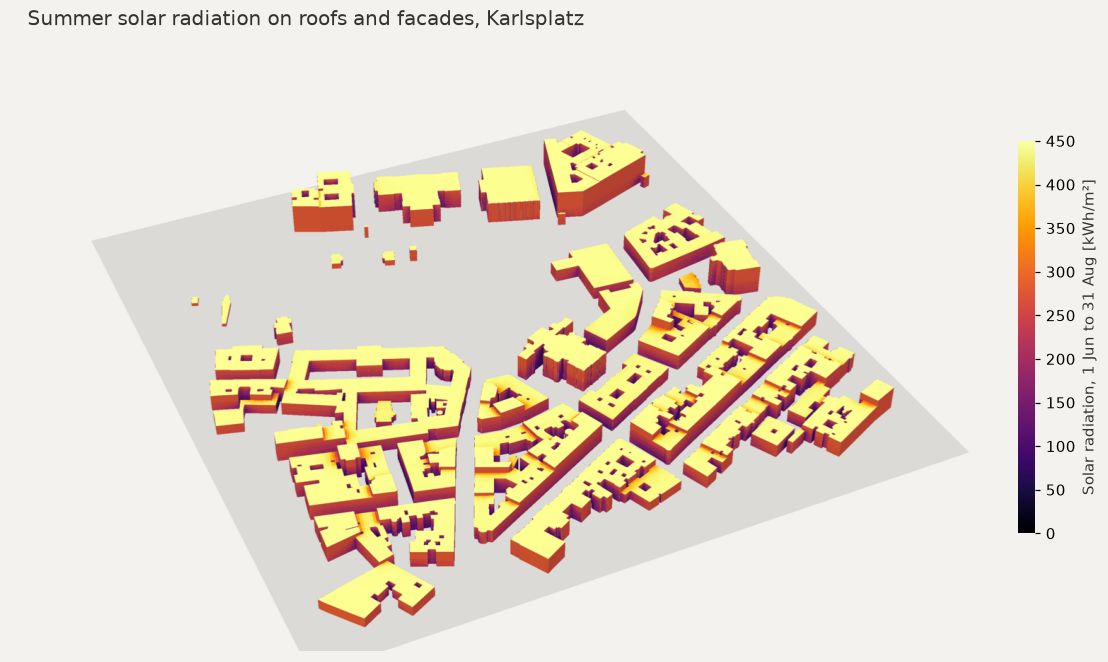

In [8]:
context = v3.mesh_from_dicts(buildings)
pl = v3.plotter()
v3.add_ground(pl, context.bounds, pad=20)
v3.add_meshes(pl, context)
v3.add_values(pl, cells, cmap="inferno", clim=(0, 450))
v3.show(pl, OUT / "04_solar_overview.png", cmap="inferno", clim=(0, 450),
        label="Solar radiation, 1 Jun to 31 Aug [kWh/m²]",
        title="Summer solar radiation on roofs and facades, Karlsplatz",
        azimuth=-25, elevation=38, zoom=1.6, focus=(290, 290, 0))

**What you see:** the roofs are bright yellow, near the top of the scale. The facades are
orange to dark red. The open space in the middle is Resselpark, in front of the Karlskirche.

Now only the facades, with a scale for facades. The view looks north, at the facades that face south.

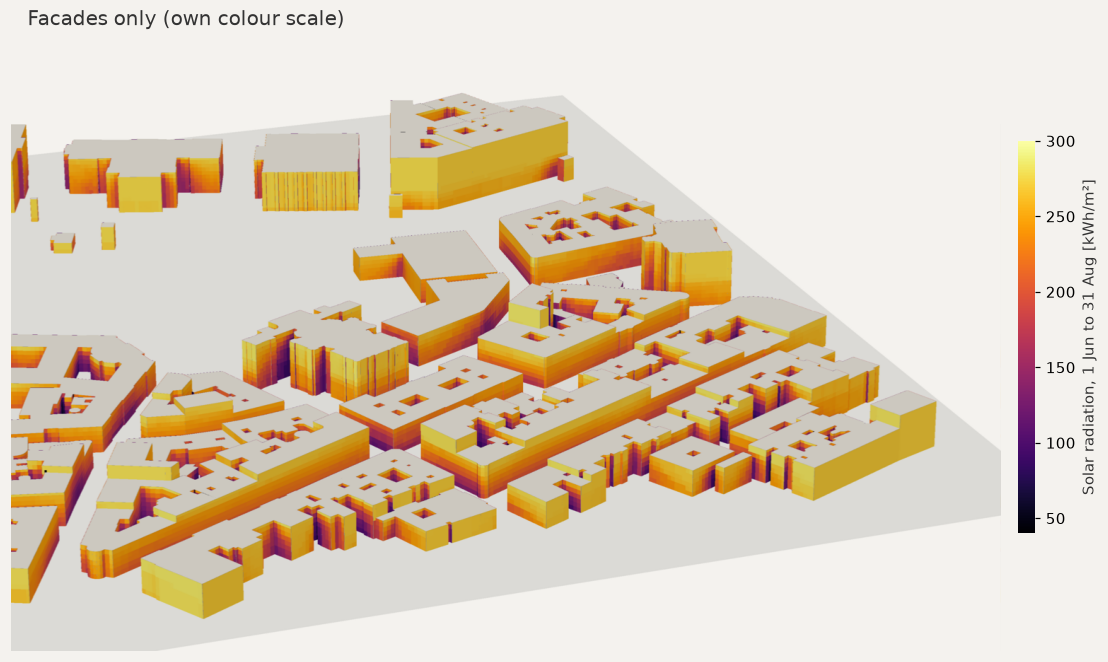

In [9]:
pl = v3.plotter()
v3.add_ground(pl, context.bounds, pad=20)
v3.add_meshes(pl, context)
v3.add_values(pl, cells.extract_cells(wall), cmap="inferno", clim=(40, 300))
v3.show(pl, OUT / "04_solar_facades.png", cmap="inferno", clim=(40, 300),
        label="Solar radiation, 1 Jun to 31 Aug [kWh/m²]", title="Facades only (own colour scale)",
        azimuth=-20, elevation=22, zoom=3.0, focus=(400, 230, 10))

**What you see:** each facade is brighter at the top and darker at street level, because the
buildings opposite shade the lower floors. Facades that face south and stand at a wide street
or a square get the most sun. Narrow courtyards stay dark.

## 8. Interactive HTML (optional)

`v3.export_html` writes one file that you can turn and zoom in a browser. The file is large
(about 7 MB here), so do not commit it: `outputs/*.html` is in `.gitignore`.

In [10]:
html = v3.export_html(OUT / "04_solar_facades.html", cells, buildings,
                      cmap="Inferno", label="kWh/m²", clim=(0, 450))
print(f"{html} ({html.stat().st_size / 1e6:.1f} MB)")

outputs/04_solar_facades.html (7.1 MB)


## Next steps

- Try `analysis_surfaces="facades"` or `"roofs"`, and `surface_grid_size=1.0` for more detail (more sensors, more jobs).
- Save the layout and the values to draw them later: [Draw facade and roof results fast](https://infrared.city/docs/sdk/#draw-facade-and-roof-results-fast).
- The same request works for sky view factor, direct sun hours and daylight availability.